# Import & Stats

In [78]:
import pandas as pd
dataframe=pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
target_col='Attrition'    #define target
# dataframe=pd.read_csv("iris_2.csv")
# target_col='species'    #define target
# scaling_type="StandardScaler"
scaling_type="MinMaxScaler"
top_col_no=20
# dataframe.columns
print("Number of attributes: ", dataframe.shape[1])
print("Number of records: ", dataframe.shape[0])
print("Stats of dataset:")
dataframe.describe()

Number of attributes:  35
Number of records:  1470
Stats of dataset:


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


# Missing & Duplicate

In [79]:
missing=dataframe.isnull().sum()
duplicate=dataframe.duplicated().sum()
print("Missing:\n",missing)
print("Duplicate: ",duplicate)
# dataframe[dataframe.duplicated(keep=False)]

Missing:
 Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0


# Data cleaning

In [80]:
#drop target null rows
dataframe.dropna(subset=[target_col],inplace=True) #cng target here
missing=dataframe.isnull().sum()
print("Missing:\n",missing)
dataframe.shape

Missing:
 Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0


(1470, 35)

In [81]:
#drop duplicate rows
dataframe.drop_duplicates(inplace=True)
duplicate=dataframe.duplicated().sum()
print("Duplicate: ",duplicate)
dataframe.shape

Duplicate:  0


(1470, 35)

In [82]:
#replace str cols with mode of that cols
non_numeric_cols = dataframe.select_dtypes(exclude=['number']).columns
# print("non numeric cols: ",non_numeric_cols)

for col in non_numeric_cols:
    mode_value = dataframe[col].mode()[0]
    # print("mode: ",mode_value)
    dataframe[col] = dataframe[col].fillna(mode_value)

missing=dataframe.isnull().sum()
print("Missing:\n",missing)

Missing:
 Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0


In [83]:
#replace numeric cols with mean of that cols
numeric_cols = dataframe.select_dtypes(include=['number']).columns
# print("numeric cols: ",numeric_cols)

mean_values = dataframe[numeric_cols].mean()
# print("mean: ",mean_values)
dataframe[numeric_cols] = dataframe[numeric_cols].fillna(mean_values)

missing=dataframe.isnull().sum()
print("Missing:\n",missing)

Missing:
 Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0


# Input & Output feature

In [84]:
#split dataframe
features=dataframe.drop(target_col,axis=1)
target=dataframe[target_col]
labels=features.columns

# Conversion of features into numeric

In [85]:
# print(features.dtypes)
#split
features_numeric=features.select_dtypes(include=['number'])
features_non_numeric=features.select_dtypes(exclude=['number'])
non_numeric_cols = features.select_dtypes(exclude=['number']).columns
# print(features_numeric)
# print(features_non_numeric)
# print("non numeric cols: ",non_numeric_cols)
# non_numeric_cols = non_numeric_cols.drop(target_col)
# print("non numeric cols: ",non_numeric_cols)

for col in non_numeric_cols:
    features_non_numeric[col]=features_non_numeric[col].astype('category')

print(features_non_numeric.dtypes)

#one hot
features_non_numeric=pd.get_dummies(features_non_numeric)
# features_non_numeric.head(5)
features_non_numeric

BusinessTravel    category
Department        category
EducationField    category
Gender            category
JobRole           category
MaritalStatus     category
Over18            category
OverTime          category
dtype: object


,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Over18_Y,OverTime_No,OverTime_Yes
0,False,False,True,False,False,True,False,True,False,False,...,False,False,True,False,False,False,True,True,False,True
1,False,True,False,False,True,False,False,True,False,False,...,False,True,False,False,False,True,False,True,True,False
2,False,False,True,False,True,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,True
3,False,True,False,False,True,False,False,True,False,False,...,False,True,False,False,False,True,False,True,False,True
4,False,False,True,False,True,False,False,False,False,True,...,False,False,False,False,False,True,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,False,True,False,False,True,False,False,False,False,True,...,False,False,False,False,False,True,False,True,True,False
1466,False,False,True,False,True,False,False,False,False,True,...,False,False,False,False,False,True,False,True,True,False
1467,False,False,True,False,True,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True
1468,False,True,False,False,False,True,False,False,False,True,...,False,False,True,False,False,True,False,True,True,False


# Conversion of target into numeric

In [86]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
target = encoder.fit_transform(target)
target

array([1, 0, 1, ..., 0, 0, 0])

# Scaling

In [87]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

#func
def Scaling(features,type): 
    if type=="StandardScaler":  
        scalar=StandardScaler()
    elif type=="MinMaxScaler":
        scalar=MinMaxScaler()
    else:
        scalar=MinMaxScaler()
        
    scaled_features=scalar.fit_transform(features)
    return scaled_features

# scaled_features=Scaling(features=features_numeric, type="MinMaxScaler")
# print("Min Max\n",scaled_features)
# scaled_features=Scaling(features=features_numeric, type="StandardScaler")
# print("Standard\n",scaled_features)

scaled_features=Scaling(features=features_numeric, type=scaling_type)
print(scaling_type+"\n",scaled_features)


MinMaxScaler
 [[0.54761905 0.71581961 0.         ... 0.22222222 0.         0.29411765]
 [0.73809524 0.12670007 0.25       ... 0.38888889 0.06666667 0.41176471]
 [0.45238095 0.90980673 0.03571429 ... 0.         0.         0.        ]
 ...
 [0.21428571 0.03793844 0.10714286 ... 0.11111111 0.         0.17647059]
 [0.73809524 0.65926986 0.03571429 ... 0.33333333 0.         0.47058824]
 [0.38095238 0.37652112 0.25       ... 0.16666667 0.06666667 0.11764706]]


# Correlation Analysis

In [88]:
#merge numeric & non_numeric
features_df=pd.DataFrame(scaled_features, columns=features_numeric.columns)
features_non_numeric=pd.DataFrame(features_non_numeric.to_numpy(), columns=features_non_numeric.columns)
features_df=pd.concat([features_df,features_non_numeric],axis=1)
target_df=pd.DataFrame(target, columns=[target_col])

traget_series=target_df[target_col]
correlations=features_df.corrwith(traget_series)
# print("Correlation:\n", correlations)

correlation_matrix=pd.DataFrame(correlations, columns=['Correlation'])
print("\nCorrelation Matrix:\n",correlation_matrix)



Correlation Matrix:
                                    Correlation
Age                                  -0.159205
DailyRate                            -0.056652
DistanceFromHome                      0.077924
Education                            -0.031373
EmployeeCount                              NaN
EmployeeNumber                       -0.010577
EnvironmentSatisfaction              -0.103369
HourlyRate                           -0.006846
JobInvolvement                       -0.130016
JobLevel                             -0.169105
JobSatisfaction                      -0.103481
MonthlyIncome                        -0.159840
MonthlyRate                           0.015170
NumCompaniesWorked                    0.043494
PercentSalaryHike                    -0.013478
PerformanceRating                     0.002889
RelationshipSatisfaction             -0.045872
StandardHours                              NaN
StockOptionLevel                     -0.137145
TotalWorkingYears                    -

c:\Users\Binary Gadget\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Binary Gadget\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


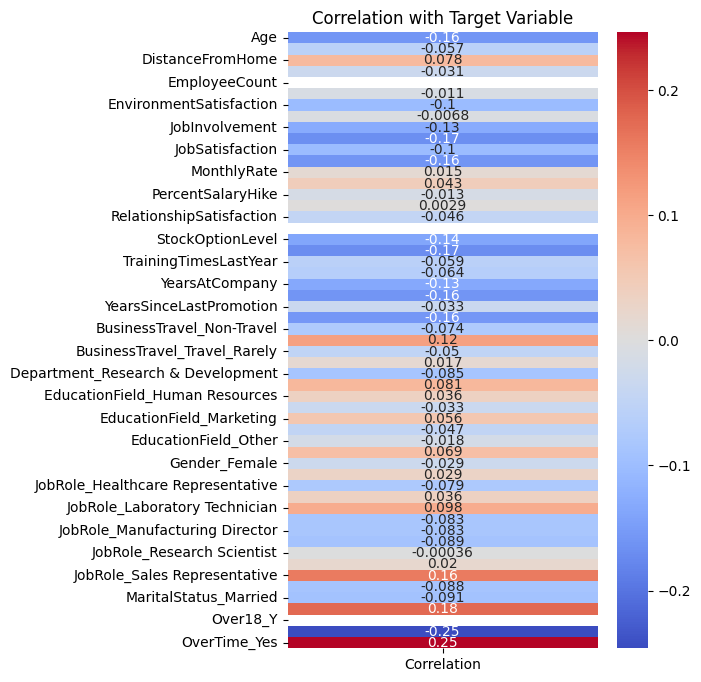

In [89]:
# Plot the correlation matrix
import matplotlib.pyplot as plt
import seaborn as sb
plt.figure(figsize=(5, 8))  
sb.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation with Target Variable')
plt.show()

In [90]:
#top 20 correlations
top_correlations=correlations.abs().nlargest(top_col_no)
print(top_correlations)
top_correlations_features=top_correlations.index
print(top_correlations_features.size)
# print(top_correlations_features[0])


OverTime_No                         0.246118
OverTime_Yes                        0.246118
MaritalStatus_Single                0.175419
TotalWorkingYears                   0.171063
JobLevel                            0.169105
YearsInCurrentRole                  0.160545
MonthlyIncome                       0.159840
Age                                 0.159205
JobRole_Sales Representative        0.157234
YearsWithCurrManager                0.156199
StockOptionLevel                    0.137145
YearsAtCompany                      0.134392
JobInvolvement                      0.130016
BusinessTravel_Travel_Frequently    0.115143
JobSatisfaction                     0.103481
EnvironmentSatisfaction             0.103369
JobRole_Laboratory Technician       0.098290
MaritalStatus_Married               0.090984
JobRole_Research Director           0.088870
MaritalStatus_Divorced              0.087716
dtype: float64
20


# Scatter Plot

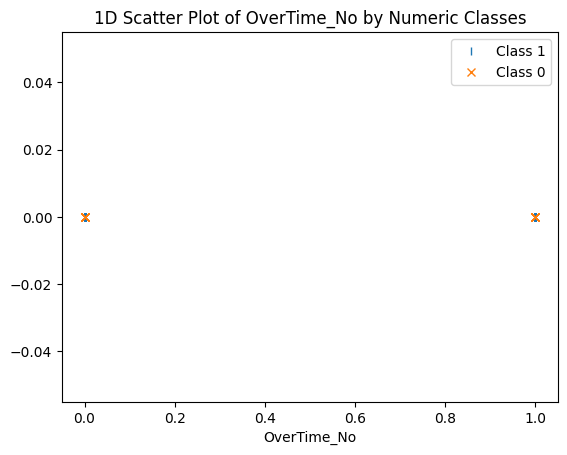

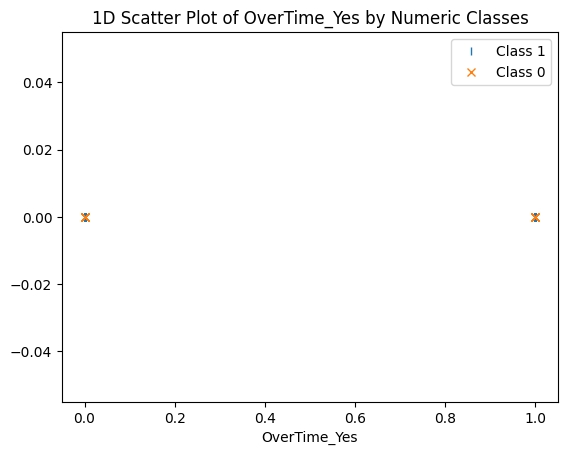

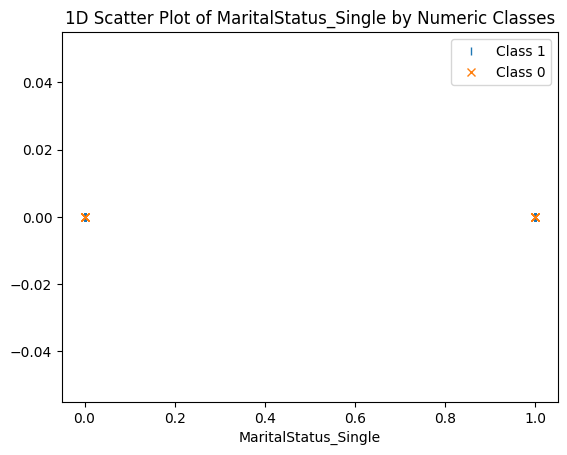

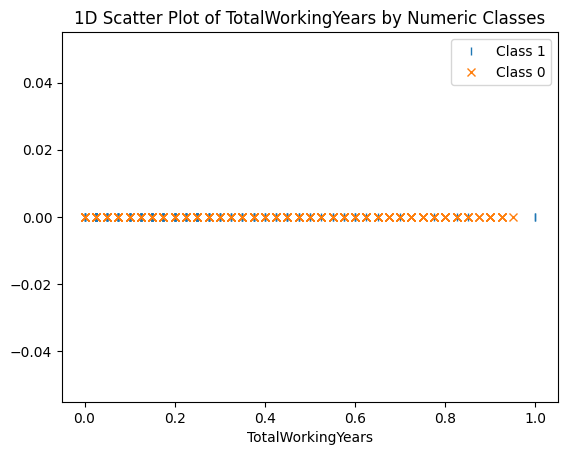

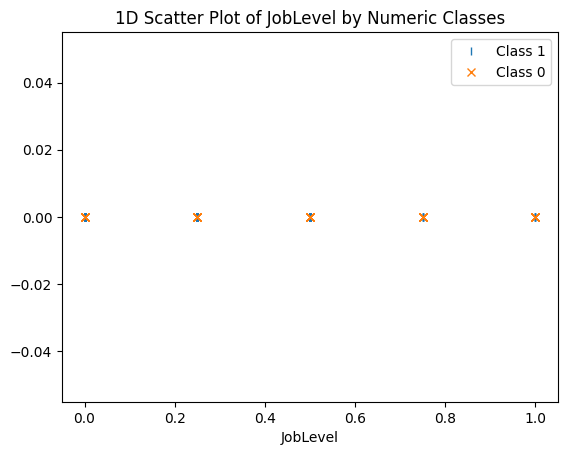

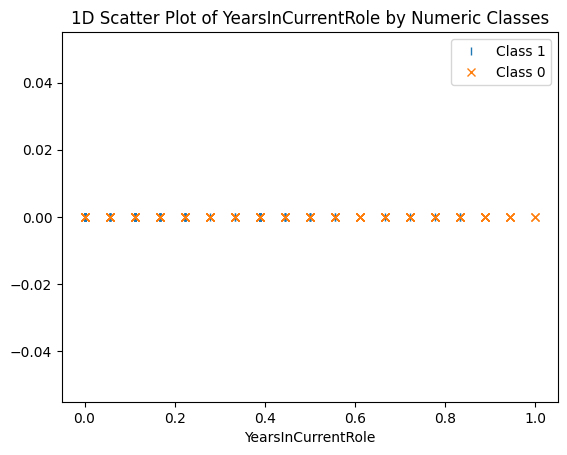

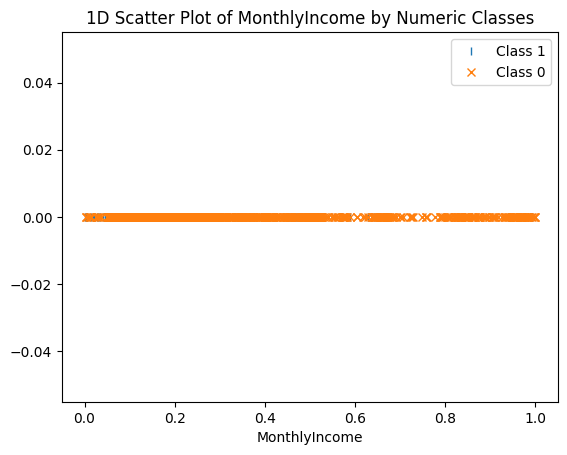

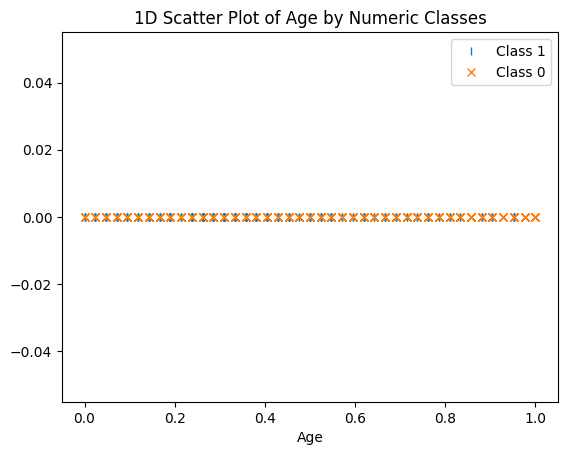

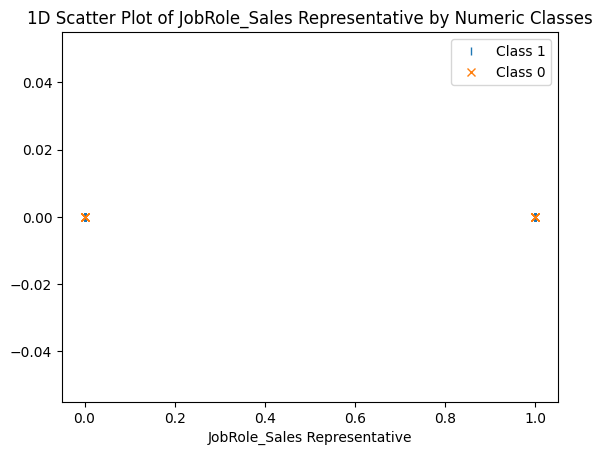

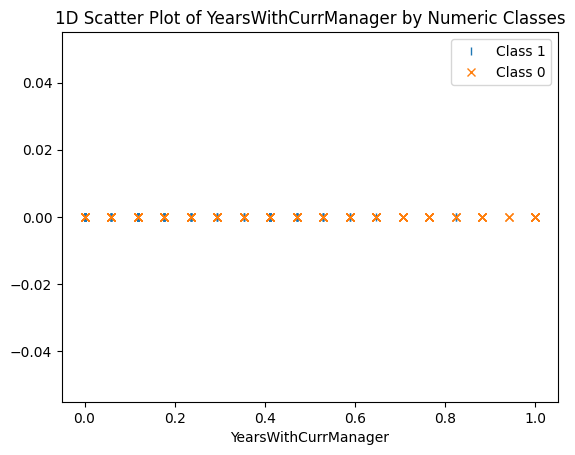

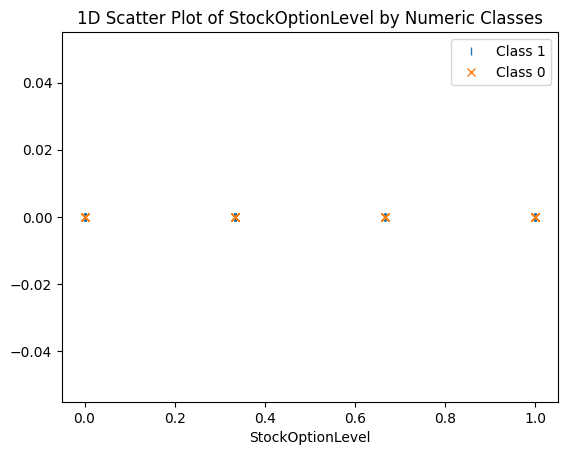

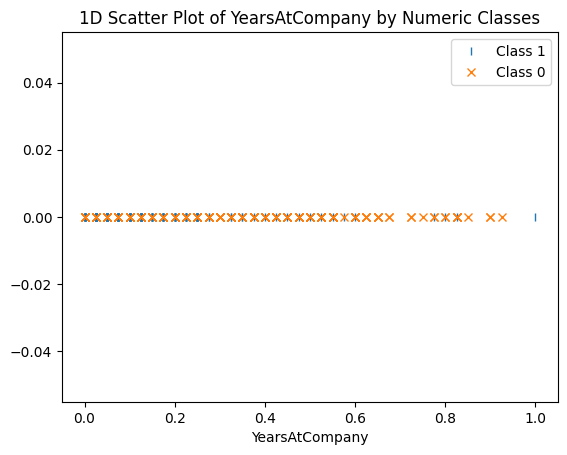

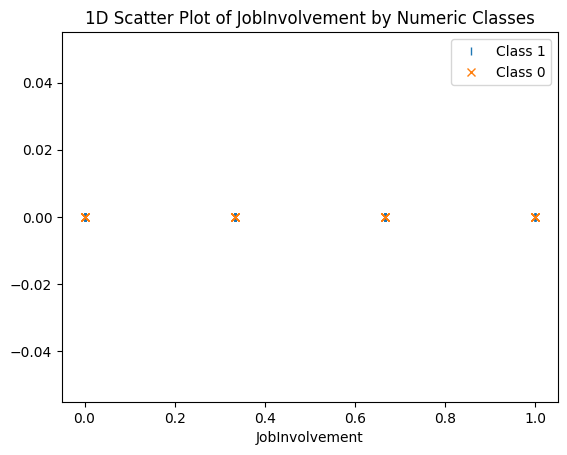

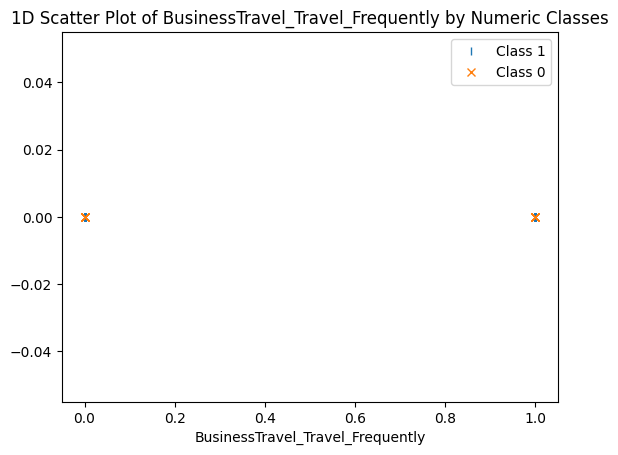

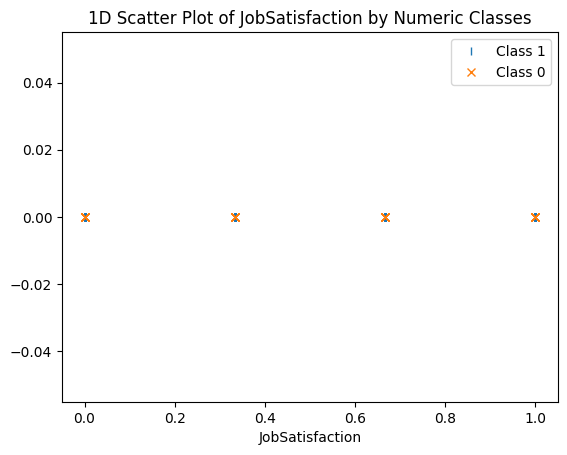

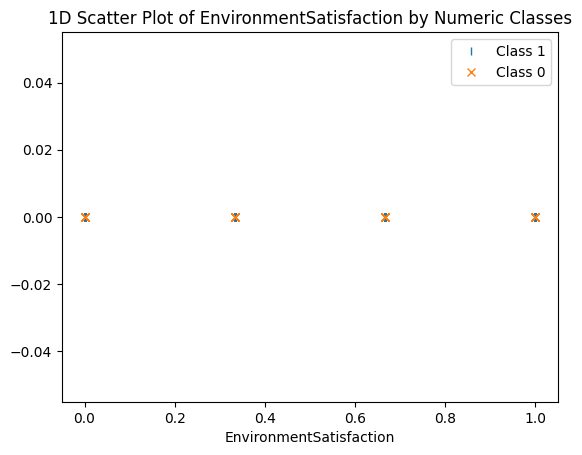

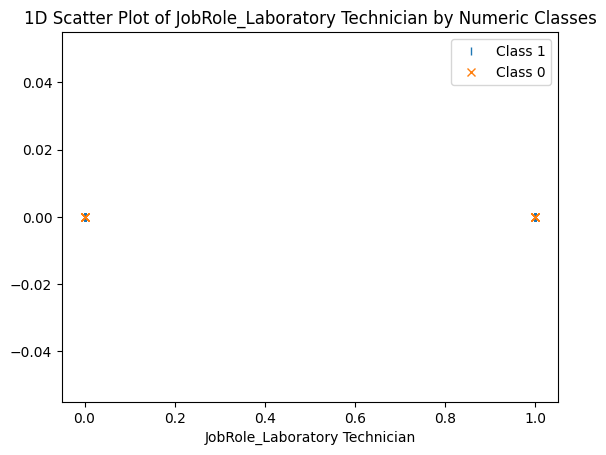

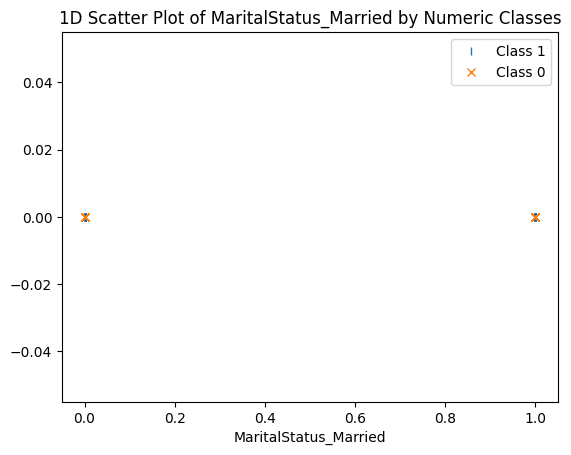

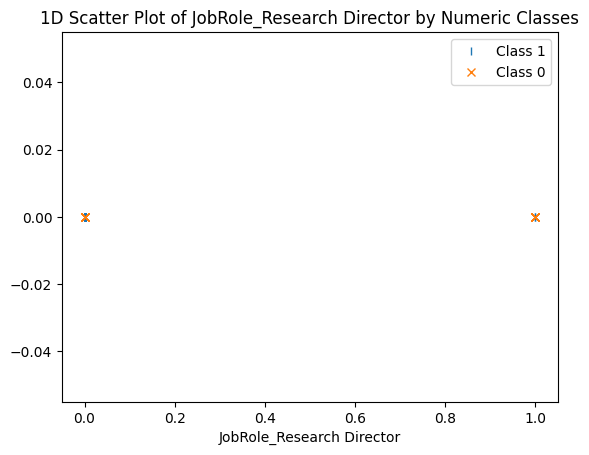

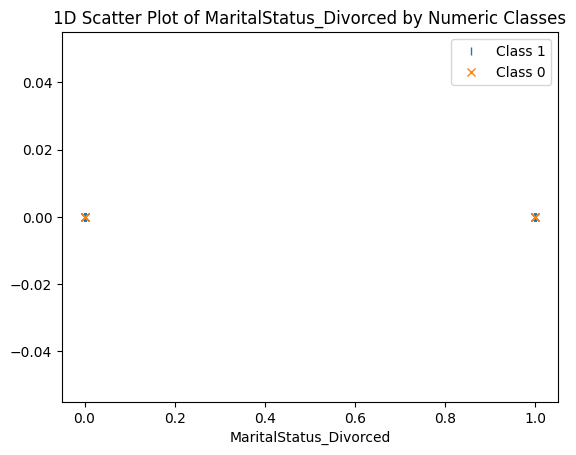

In [91]:
import matplotlib.pyplot as plt
import numpy as np 

def Plot(target_col,feature_name): #generalized kore, based on target
    # Separate the data based on numeric labels
    target_label=target_df[target_col].unique()
    # print(target_label)
    for i in target_label:
        class_0 = features_df.loc[target_df[target_col] == i]
        if i==0:
            plt.plot(class_0[feature_name], np.zeros_like(class_0[feature_name]), 'x', label=f'Class {i}')
        else:
            plt.plot(class_0[feature_name], np.zeros_like(class_0[feature_name]), '|', label=f'Class {i}')

    plt.legend()
    plt.xlabel(feature_name)
    plt.title('1D Scatter Plot of '+ feature_name +' by Numeric Classes')
    plt.show()

for tf in top_correlations_features:
    Plot(target_col,tf)

# Validating the pipeline

In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

def Prediction(x,y):
    x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

    model = LogisticRegression()
    # print(x_train)
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

#only with top 20 features
# print(top_correlations_features)
# top_features=features[list(top_correlations_features)]
# print(top_features)
# x=Scaling(features=top_features, type=scaling_type)
# print(x)

x=features_df[list(top_correlations_features)]  #f_df already scaled
y=target
print(f"Accuracy of Logistic Regression classifier with {scaling_type}: {Prediction(x,y):.2f}")

# x=Scaling(features=features_df[list(top_correlations_features)], type="StandardScaler")
# y=target
# print(f"Accuracy of Logistic Regression classifier with Standard scalar: {Prediction(x,y):.2f}")


Accuracy of Logistic Regression classifier with MinMaxScaler: 0.87
